In [1]:
import os
from functools import lru_cache
import copy
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import scipy.sparse as sp
from scipy.sparse import csr_matrix, diags
from scipy.linalg import lu_factor, lu_solve, solve
#from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform

import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset


In [2]:

def unitcell(w, d, t, e, m):
    dim = 2 * m
    base_val = (w + 1j*d)
    base = base_val * np.eye(2*m)
    idy = np.arange(0,2*m-1,1)
    base[idy,idy+1] = t
    base[idy+1,idy] = t
    idx = np.arange(0,m,2)
    base[idx,2*m-1-idx] = t
    base[2*m-1-idx,idx] = t

    return base 


def connection(t,m):
    idx = np.arange(2,m,2)
    base = np.zeros((2*m,2*m),dtype=np.complex64)

    base[2*m - idx,idx - 1] = t 
#    base[2*m - idx,2*m - idx] = t 
    return base



def T1_matrix(t, m):
    dim = 2 * m
    T = np.zeros((dim, dim), dtype=np.complex128)

    n = np.arange(1, (m - 1)//2 + 1)
    i = 2*n - 1           # to 0-based
    j = 2*m - 2*n

    T[i, j] = t
    return T



def rho_matrix(t, m):
    
    dim = 2 * m
    rho = np.zeros((dim, dim), dtype=complex)
    for n in range(1, (m - 1) // 2 + 1):
        idx = 2 * n - 1
        rho[idx, idx] = t
    return rho


In [3]:
DEVICE_COMBS = {}


def _get_device_combs(width: int) -> np.ndarray:
    """
    Return (global cached) device combinations for a given width.
    Each row is (i, j) with i in [0..99] and j in [0..width-1].
    """
    width = int(2*width)
    if width not in DEVICE_COMBS:
        # Build once, store once
        DEVICE_COMBS[width] = np.stack(
            np.meshgrid(np.arange(100), np.arange(width), indexing="ij"),
            axis=-1
        ).reshape(-1, 2)
    return DEVICE_COMBS[width]


@lru_cache(maxsize=2048)
def chosen_for_config(n: int, width: int, config: int) -> np.ndarray:
    """
    Return n rows selected deterministically by given config.
    Completely cached.
    """
    n = int(n)
    width = int(width)
    config = int(config)

    device_combs = _get_device_combs(width)

    rng = np.random.RandomState(config)
    idx = rng.choice(len(device_combs), size=n, replace=False)
    return device_combs[idx]


def possible_combs(n: int, width: int):
    n = int(n)
    width = int(width)

    def combs_for_seed(seed: int):
        return chosen_for_config(n, width, seed)

    return combs_for_seed


def unidevice(w, d, t, e, size, config, n, numberofunitcell, combs_fn=None):
    """
    Build a device Hamiltonian unit with impurities inserted at positions
    determined by 'config'. Uses vectorised assignments where possible.
    """

    size = int(size)

    
    if combs_fn is None:
        combs_fn = possible_combs(int(n), int(size))

    # Chosen impurity coordinates
    imps = combs_fn(int(config))
    x = imps[:, 0]
    y = imps[:, 1]

    z = int(numberofunitcell)

    # Base Hamiltonian (already cached inside your unitcell_leads)
    mat = unitcell(w, d, t, e, int(size))

    # Identify impurities in unitcell z
    mask = (x == z)
    if not np.any(mask):
        return mat  # fast path return

    imp_indices = y[mask]

    # Vectorised diagonal modification
    diag_val = (w + 1j*d - 0.5)
    mat[imp_indices, imp_indices] = diag_val

    return mat


In [4]:
leads_path = os.getcwd()
print(leads_path)

/Users/shardul/Inverse_problems_in_QM/notebooks/agnr


In [5]:
g_7 = np.load(
    os.path.expanduser('../../leads/agnr/size_7/leads_7.npy'), mmap_mode="r"
)

In [6]:
g_7.shape

(300, 14, 14)

In [7]:
def device_transmission(w, d, t, e, size, config, concentration):
    ene = int(w * 100)
    m = size
    dim = 2 * m
    I = np.eye(dim, dtype=complex)

    # 1. Lead Surface Green's Functions:
    left = g_7[ene]                   # Left lead surface Green's function
    #P = np.eye(dim)[::-1]
    #right = P @ left @ P                  # Right lead surface Green's function (g_R = P g_L P)

    # 2. Hopping Matrices:
    #T1 = T1_matrix(t, m)     
    tin = T1_matrix(t, m)
    tin_d = tin.T             # Forward hopping T
    #Tcon = connection(t, m)               # Backward hopping T^\dagger
    rho = rho_matrix(t, m)                # Contact operator \[Rho]

    # 3. Device Propagation (100 Unit Cells):
    combs_fn = possible_combs(concentration, size)
    g_new = left

    for i in range(100):
        unit_i = unidevice(w, d, t, e, size, config, concentration, i, combs_fn=combs_fn)
        gd = np.linalg.inv(unit_i)
        G = np.linalg.solve(I - gd @ tin_d @ g_new @ tin, gd)
        g_new = G

    left_device = g_new

    # 4. Connected Interface Green's Functions using Mathematica's rho matrix:
    IL = np.linalg.solve(I - left_device @ rho @ left @ rho, left_device)
    IR = np.linalg.solve(I - left @ rho @ left_device @ rho, left)

    # 5. Spectral Functions & Non-local Cross Green's Function:
    gdd = IL - IL.conj().T
    grr = IR - IR.conj().T

    Gnonlocal = left @ rho @ IL
    GNON = Gnonlocal - Gnonlocal.conj().T

    # 6. Mathematica Trace Calculation:
    term1 = gdd @ rho @ grr @ rho
    term2 = rho @ GNON @ rho @ GNON

    tr1 = np.abs(np.trace(term1 - term2))

    return tr1

(0.0, 3.5)

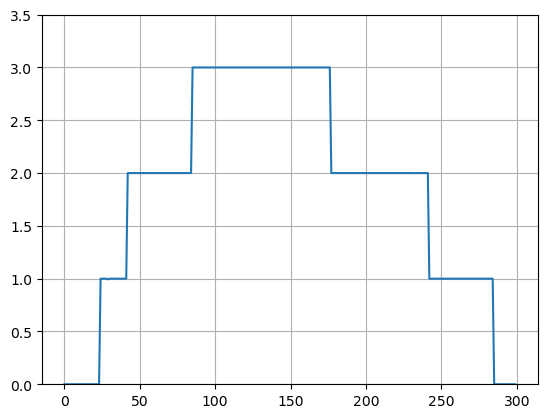

In [9]:
plt.grid()
plt.plot([device_transmission(w, 1e-5, 1, 0, 7, 40, 0) for w in np.arange(0,3,0.01)])
#plt.plot([device_transmission(w, 1e-5, 1, 0, 9, 40, 21) for w in np.arange(0,3,0.01)])
#plt.plot([device_transmission(w, 1e-5, 1, 0, 9, 41, 21) for w in np.arange(0,3,0.01)])
plt.ylim(0,3.5)

In [33]:
pristine = [device_transmission(w, 1e-5, 1, 0, 7, 0, 0) for w in np.arange(0,3,0.01)]
np.save("../../7_agnr_pris.csv",pristine)

In [23]:
@lru_cache(1028)
def ca(conc):
    df = []
    d1 = [np.clip(np.load(os.path.join(file_path + f'size_9_{conc}/9_agnr_conc{conc}_cfg{config}.npy')), 0, pristine) for config in range(10000)]
    df.append(d1)

    return np.mean(df, axis=1)

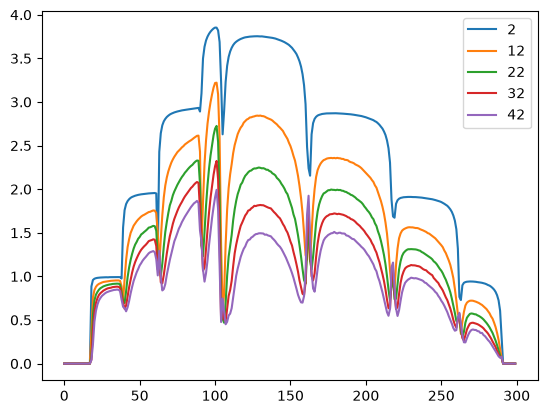

In [24]:
for conc in np.arange(2,43,10):
    plt.plot(ca(conc)[0], label= f'{conc}')

plt.legend()

In [45]:
input_1 = np.clip(np.array([device_transmission(w,1e-5,1,0,9,10079,16) for w in np.arange(0,3,0.01)]),0,pristine)

In [46]:
def misfit(input):
    input = np.array(input)
    input = np.clip(input, 0, pristine)
    
    # Calculate misfits
    concs = np.arange(2, 50, 2)
    mis_1 = [np.sum((np.abs(input - ca(con)[0])[20:150])**2)/150 for con in concs]
    mis_1 = np.array(mis_1)

    # 1. Find the index of the minimum value
    min_idx = np.argmin(mis_1)
    minima_val = mis_1[min_idx]

    # 2. Calculate Curvature of the misfit curve
    # We use np.gradient to get derivatives relative to the concentration steps
    dx = np.gradient(concs)
    dy = np.gradient(mis_1)
    
    d2x = np.gradient(dx)
    d2y = np.gradient(dy)

    # Standard formula for curvature kappa
    curvature_array = np.abs(dx * d2y - dy * d2x) / (dx**2 + dy**2)**1.5
    
    # 3. Extract curvature at the specific minima index
    curvature_at_minima = curvature_array[min_idx]

    return mis_1,min_idx,curvature_at_minima

14
0.005444213459359005


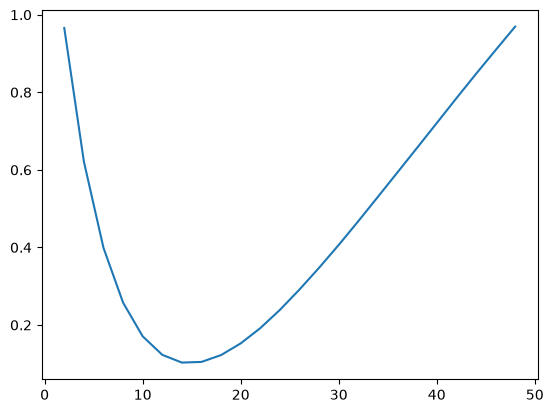

In [47]:
a,b,c = misfit(input_1)

plt.plot(np.arange(2,50,2),a)
print(np.arange(2,50,2)[b])
print(c)

In [37]:
con_err = []
for c in np.arange(1,50,3):
    mis, min = misfit(c)
    
#    print(np.array(min).reshape(-1))
    err = np.sum(np.abs((np.array(min).reshape(-1)) - c)/c)/100
    con_err.append(err)

    print(f"Error for concentration {c} is : ====>>>> {err}")

    

TypeError: cannot unpack non-iterable numpy.float64 object

In [48]:
@lru_cache(maxsize=1024)
def impurity_distance_matrix(conc,size, config):
    imps  = possible_combs(conc, size)
    item = imps(config)
    #print(np.diag(item[:,1]))
    x = np.stack((size - item[:,1],item[:,1]), axis=1)
    return squareform(pdist(item, metric='euclidean')) + np.diag(x.min(axis=1))

In [60]:
print("Creating manifest file...")

# This will store the info for each s#ample
manifest_data = []
# Define the root directory where files are stored
root_dir = os.path.expanduser(
    '~/transmission_results/'
)

# Use the same loops as your original script
for conc in np.arange(2, 53, 2):
    for config in range(10000):
        # We just construct the path, we don't load the file here
        path = f'size_9_{conc}/'+f'9_agnr_conc{conc}_cfg{config}.npy'
        full_path = os.path.join(root_dir, path)

        # Check if the file actually exists before adding it to the manifest
        if os.path.exists(full_path):
            manifest_data.append({
                "concentration": conc,
                "config_id": config,
                "filepath": path  # Store the relative path
            })

# Convert the list of data into a pandas DataFrame
manifest_df = pd.DataFrame(manifest_data)

# Save the manifest to a CSV file
manifest_df.to_csv("manifest_agnr.csv", index_label="id")

print(f"Done! Created manifest.csv with {len(manifest_df)} entries.")

Creating manifest file...
Done! Created manifest.csv with 260000 entries.


In [67]:
class transmissions_dataset(Dataset):
    def __init__(self, manifest_file, root_dir, matrix_size=52):
        self.manifest = pd.read_csv(manifest_file, index_col="id")
        self.root_dir = root_dir
        self.matrix_size = matrix_size
        
        if pristine is None:
            raise ValueError("You must pass pristine array when creating the dataset.")
        self.pristine = np.asarray(pristine)

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        sample_info = self.manifest.iloc[idx]

        conc   = int(sample_info["concentration"])
        config = int(sample_info["config_id"])
        size   = self.matrix_size   # <= used for distance matrix

        # ----------------------------------------------------
        # 1) Load and process transmission
        # ----------------------------------------------------
        filepath = os.path.join(self.root_dir, sample_info["filepath"])
        transmission = np.load(filepath)

        trans = transmission
        pris  = self.pristine
        trans = np.clip(trans, 0, pris)

        x = torch.tensor(trans, dtype=torch.float32)

        # ----------------------------------------------------
        # 2) Distance matrix from impurities (FAST version)
        # ----------------------------------------------------
        # Call signature: (conc, size, config)
        dist_small = impurity_distance_matrix(conc, size, config)

        # zero-pad
        dist_mat = np.zeros((size, size))
        dist_mat[:conc, :conc] = dist_small

        D = torch.tensor(dist_mat, dtype=torch.float32)

        # ----------------------------------------------------
        # 3) Label = concentration
        # ----------------------------------------------------
        y = torch.tensor([conc], dtype=torch.float32)

        # ----------------------------------------------------
        # Return without D if you're not training with it yet
        # ----------------------------------------------------
        return x, y
        # return x, y, D   # uncomment when training with D


In [68]:
dataset = transmissions_dataset(manifest_file='manifest_agnr.csv', root_dir=os.path.expanduser('~/transmission_results/'))

In [69]:
dataset[-1]

(tensor([4.0000e-09, 4.0207e-09, 4.0842e-09, 4.1940e-09, 4.3572e-09, 4.5847e-09,
         4.8934e-09, 5.3093e-09, 5.8731e-09, 6.6506e-09, 7.7535e-09, 9.3834e-09,
         1.1935e-08, 1.6272e-08, 2.4609e-08, 4.4175e-08, 1.1151e-07, 8.2519e-07,
         1.1439e-03, 4.0590e-02, 3.3584e-01, 3.4962e-01, 7.8488e-01, 3.9919e-01,
         3.7341e-01, 3.3051e-01, 5.5558e-01, 5.8687e-01, 9.7999e-01, 6.1752e-01,
         8.6966e-01, 8.0184e-01, 7.1806e-01, 7.2042e-01, 9.9501e-01, 7.6508e-01,
         8.1745e-01, 9.0160e-01, 2.2212e-01, 5.9130e-01, 5.2872e-01, 9.0909e-01,
         3.8911e-01, 1.7797e-01, 1.4178e+00, 1.5058e+00, 1.0528e+00, 1.3709e+00,
         1.0671e+00, 1.1218e+00, 1.4045e+00, 9.0511e-01, 1.0691e+00, 1.8039e+00,
         1.1648e+00, 1.1806e+00, 1.3172e+00, 1.1963e+00, 9.0391e-01, 7.6316e-01,
         7.6466e-01, 9.4479e-01, 1.8524e-01, 3.0000e+00, 4.3431e-01, 7.2801e-02,
         5.8497e-01, 1.0190e+00, 2.4956e-01, 3.2676e-01, 2.4481e-01, 1.7652e+00,
         1.0058e+00, 1.5087e

In [ ]:
class TestingDataset(Dataset):
    def __init__(self, data_test, pristine, matrix_size=52):
        """
        data_test: dict[conc] -> list[config_idx] -> list[w] (transmission values)
        pristine: 1D np.array of same length as each transmission curve (e.g. 300)
        """
        self.data_test = data_test
        self.pristine  = np.asarray(pristine)
        self.matrix_size = matrix_size
        # Build index map: flatten (conc, config_idx) pairs
        self.index_map = []
        for conc in sorted(data_test.keys()):
            num_configs = len(data_test[conc])
            for config_idx in range(num_configs):
                self.index_map.append((conc, config_idx))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        conc, config_idx = self.index_map[idx]
        size = self.matrix_size
        # transmission curve: list over w
        trans = np.asarray(self.data_test[conc][config_idx], dtype=np.float32)

        # clip against pristine
        trans = np.clip(trans, 0, self.pristine)

        x = torch.tensor(trans, dtype=torch.float32)         # shape [300] (or whatever length)
        y = torch.tensor([conc], dtype=torch.float32)        # label is the concentration

        dist_small = impurity_distance_matrix(conc, size, config)

        # zero-pad
        dist_mat = np.zeros((size, size))
        dist_mat[:conc, :conc] = dist_small

        D = torch.tensor(dist_mat, dtype=torch.float32)
        return x, D


In [79]:
class Conductance_Inversion_CNN(nn.Module):
    def __init__(self, input_length=200, final_hidden_dim=512):
        super().__init__()
        
        # 1. Feature Extraction (1D CNN layers)
        # Input shape: [Batch, 1, 200]
        self.conv_features = nn.Sequential(
            # Layer 1: Detect basic features (width 5)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1,2)),  # Output size: 100
            nn.Dropout(0.3),

            # Layer 2: Detect complex/aggregated features
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1,2)),  # Output size: 50
            nn.Dropout(0.3),
            
            # Layer 3: Deeper feature aggregation
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1,2)),
            nn.Dropout(0.3),
            
            # Layer 3: Deeper feature aggregation
            nn.Conv2d(in_channels=32, out_channels=final_hidden_dim, kernel_size=(1, 3), padding=(0, 1)),
            nn.ReLU(),
            nn.Dropout(0.3)

        )
        
        # 2. Global Aggregationx
        # Condenses all features into a single, fixed-size vector
        self.aggregator = nn.AdaptiveAvgPool2d((1,2))
        
        # 3. Regression Head (Fully Connected layers)
        # Maps the extracted features to the scalar output 'n'
        self.regressor = nn.Sequential(
            nn.Linear(final_hidden_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 50*50) # Output: Concentration 'n' (scalar)
        )

    def forward(self, x):
        # x must be reshaped for Conv1D: [Batch, Length] -> [Batch, 1, Length]
        x = x.unsqueeze(1).unsqueeze(2)
        
        # Feature Extraction
        x = self.conv_features(x)
        
        # Aggregation: Resulting size is [Batch, final_hidden_dim, 1]
        x = self.aggregator(x)
        
        x = x.view(x.size(0),-1)

        x= self.regressor(x)
        # Flatten and Regression: [Batch, final_hidden_dim]
        x = x.view(-1,50,50)
        
        return x

In [80]:

def training_model(dataset, num_epochs, val_split, device=None):
    # 1. Device defined properly at the top
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    # Initialize model and move it to the device FIRST
    model = Conductance_Inversion_CNN(input_length=200, final_hidden_dim=256).to(device)
    
    # NOW initialize the optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=3
    )
    
    # Split Data
    n_val = int(len(dataset) * val_split)
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val])

    train_loader = DataLoader(train_ds, shuffle=True, batch_size=32)
    val_loader   = DataLoader(val_ds, shuffle=False, batch_size=32)

    train_loss_history = []
    val_loss_history   = []
    
    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(num_epochs):
        # -----------------------
        #      TRAINING
        # -----------------------
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)        # [batch, 200]
            yb = yb.to(device)        # [batch, 50, 50]

            # Forward pass (Removed the .squeeze() calls!)
            preds = model(xb)         # Output is [batch, 50, 50]
            
            # --- THE MISFIT CALCULATION ---
            # Note: This is currently calculated on the inputs (xb).
            # If this is meant to regularize predictions, it needs to be calculated on `preds`.
            # If it stays as is, it must be rewritten using purely PyTorch operations.
            misfit_term = torch.tensor([misfit(x.detach().cpu().numpy()) for x in xb], 
                                       dtype=torch.float32, device=device).mean()

            loss = F.mse_loss(preds, yb) + misfit_term
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train = running_loss / len(train_loader)
        train_loss_history.append(avg_train)

        # -----------------------
        #     VALIDATION
        # -----------------------
        model.eval()
        running_val = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb)
                
                misfit_term = torch.tensor([misfit(x.detach().cpu().numpy()) for x in xb], 
                                           dtype=torch.float32, device=device).mean()
                                           
                loss = F.mse_loss(preds, yb) + misfit_term

                running_val += loss.item()

        avg_val = running_val / len(val_loader)
        val_loss_history.append(avg_val)
        
        # -----------------------
        # UPDATES & CHECKPOINTING
        # -----------------------
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} * Saved Best")
        else:
            print(f"Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    # -----------------------
    #     FINALIZE
    # -----------------------
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(f"\nTraining Complete. Loaded best model with Val Loss: {best_val_loss:.4f}")

    # PLOT LOSSES
    plt.figure(figsize=(10,6))
    plt.plot(train_loss_history, label="Train Loss")
    plt.plot(val_loss_history, label="Validation Loss")
    best_epoch_idx = val_loss_history.index(best_val_loss)
    plt.axvline(best_epoch_idx, color='green', linestyle='--', label='Best Model')
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    return model, (train_loss_history, val_loss_history)

In [81]:
trained_model = training_model(dataset,50,0.2)

Training on: cpu


RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x512 and 256x512)

In [ ]:
torch.save(model.state_dict(), os.path.expanduser("~/machine_learning/transmission_github/transmissions/models/trained/pinn_agnr.pth"))

In [21]:
model = Conductance_Inversion_CNN()

model.load_state_dict(torch.load(os.path.expanduser("~/machine_learning/transmission_github/transmissions/models/trained/pinn_agnr.pth")))

RuntimeError: Error(s) in loading state_dict for Conductance_Inversion_CNN:
	size mismatch for conv_features.0.weight: copying a param with shape torch.Size([16, 1, 3]) from checkpoint, the shape in current model is torch.Size([32, 1, 3]).
	size mismatch for conv_features.0.bias: copying a param with shape torch.Size([16]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for conv_features.3.weight: copying a param with shape torch.Size([32, 16, 3]) from checkpoint, the shape in current model is torch.Size([32, 32, 2]).
	size mismatch for conv_features.10.weight: copying a param with shape torch.Size([64, 32, 3]) from checkpoint, the shape in current model is torch.Size([64, 32, 2]).

In [ ]:
def test_model_with_misfit(model, test_dataset, batch_size=32):
    """
    Test model using MSE + misfit term, same as training.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb).squeeze(-1)
            yb    = yb.squeeze(-1)

            # Misfit term computed per sample, avg over batch
            misfit_term = torch.tensor(
                [misfit(x.detach().cpu().numpy()) for x in xb],
                dtype=torch.float32,
                device=device
            ).mean()

            loss = F.mse_loss(preds, yb) #+ misfit_term
            total_loss += loss.item()

            all_preds.append(preds.cpu())
            all_labels.append(yb.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    avg_loss = total_loss / len(test_loader)
    print(f"\nTest Loss (MSE + misfit): {avg_loss:.4f}")

    return all_preds, all_labels, avg_loss


In [ ]:
# 1. Build pristine reference (same length as transmission, e.g. 300 or 200)
# pristine = ...  # must exist already; you were using it in training

# 2. Create test dataset
test_dataset = TestingDataset(data_test, pristine)

# 3. Call testing
preds, labels, test_loss = test_model_with_misfit(model, test_dataset, batch_size=32)

# 4. Inspect the first few predictions
for i in range(10):
    print(f"Sample {i:02d} | True conc: {labels[i]:.1f} | Pred: {preds[i]:.2f}")



Test Loss (MSE + misfit): 68.2823
Sample 00 | True conc: 10.0 | Pred: 10.32
Sample 01 | True conc: 10.0 | Pred: 12.85
Sample 02 | True conc: 10.0 | Pred: 9.74
Sample 03 | True conc: 10.0 | Pred: 10.98
Sample 04 | True conc: 10.0 | Pred: 9.03
Sample 05 | True conc: 10.0 | Pred: 9.94
Sample 06 | True conc: 10.0 | Pred: 11.41
Sample 07 | True conc: 10.0 | Pred: 9.09
Sample 08 | True conc: 10.0 | Pred: 10.53
Sample 09 | True conc: 10.0 | Pred: 10.53


In [ ]:
labels

array([ 5.,  5.,  5., ..., 47., 47., 47.], shape=(1485,), dtype=float32)

In [ ]:
results = pd.DataFrame()

In [ ]:
results['labels']  = labels
results['predictions'] = preds

results['error'] = abs(preds-labels)

In [ ]:
results

,labels,predictions,error
0,10.0,10.323322,0.323322
1,10.0,12.854054,2.854054
2,10.0,9.735515,0.264485
3,10.0,10.976416,0.976416
4,10.0,9.030634,0.969366
...,...,...,...
688,70.0,49.799889,20.200111
689,70.0,52.669537,17.330463
690,70.0,54.236786,15.763214
691,70.0,51.362221,18.637779


In [ ]:
results.groupby('labels').agg('mean')

,predictions,error
labels,,
10.0,10.483503,0.771105
20.0,20.538908,1.280122
30.0,31.226166,2.100476
40.0,40.461735,1.752542
50.0,46.651035,3.373244
60.0,50.260460,9.739540
70.0,52.185307,17.814695
